In [ ]:
!pip3 install -U transformers python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 41.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

In [ ]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

<br><br>

## **Set parameters and file paths**

In [ ]:
# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.
model_name = 'distilbert-base-cased'

# Use CPU (no GPU). Set to 'cuda' if GPU available.
device_name = 'cuda'

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

<br><br>

## **Load and sample Goodreads data**

In [ ]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

In [ ]:
import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [ ]:
for _genre, _reviews in genre_reviews_dict.items():
  print(_genre)
  print(random.sample(_reviews, 1)[0])

poetry
One of my favorite books of poetry. Beautiful.
children
Fun.
comics_graphic
see full review @ Katie's Corner 
 Let's just say that this review is appearing totally randomly on the blog. First of all, at the time I am writing the review (it's October FYI), the story is completed but it's not fully translated in English. I can even say there are more chapters translated and uploaded in Russian. I will be making two reviews, I might make a third one, but I'm not 100% sure about that, as first I'll need to read the story to the end and for that I guess if by the time the review hits blog, which is right now, there's no new updates, I'll have to buy last 6 volumes in German. Though I'll have one advantage. I'll resurrect my German skills. Good bargain if you ask me. 
 But let me get back to the review! I'm covering 1/3 of the whole series, and I stopped right where the author says: end of part one. So that I do not mix two different lives together. The story is fantastic and it is th

In [ ]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

<br><br>

## **Split the data into training and test sets**

In [ ]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

In [ ]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

Here's an example of a training label and review:

In [ ]:
train_labels[0], train_texts[0]

('poetry',
 'The Anthologist is about a poet who believes poems should rhyme. Also, he\'s having some trouble with his girlfriend, smaller troubles with his dog and a mouse, and he has an intro to an anthology he needs to finish. This isn\'t "save the earth from a falling satellite" kind of trouble, but enough to keep a reader, at least a reader like me, going. I think Vonnegut wrote something along the lines of just sticking something between a character\'s teeth that he wants out, and that a writer is likely to keep going just to see what happens. The good stuff in The Anthologist for me was in the clever funny lines. Here\'s one of those: \n "That\'s what I call a poem that doesn\'t rhyme--it\'s a plum. We who write and publish our nonrhyming plums aren\'t poets, we\'re plummets. Or plummers." \n The protagonist\'s live-in girlfriend breaks up with him. He sees her on a date. He mostly accepts this and notes, "If you break up with someone, you get to go out with someone else." \n Ex

In [ ]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

In [ ]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

In [ ]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.62      0.65      0.64       200
        comics_graphic       0.79      0.69      0.73       200
    fantasy_paranormal       0.44      0.35      0.39       200
     history_biography       0.55      0.53      0.54       200
mystery_thriller_crime       0.49      0.50      0.49       200
                poetry       0.63      0.77      0.69       200
               romance       0.58      0.65      0.61       200
           young_adult       0.46      0.44      0.45       200

              accuracy                           0.57      1600
             macro avg       0.57      0.57      0.57      1600
          weighted avg       0.57      0.57      0.57      1600



In [ ]:
# Hugging Face login from .env (HF_TOKEN)
import os
from dotenv import load_dotenv
from huggingface_hub import login
load_dotenv()
hf_token = os.getenv("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print('Logged in to Hugging Face Hub (themaverick1)')
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

Logged in to Hugging Face Hub (themaverick1)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

In [ ]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [ ]:
label2id.keys()

dict_keys(['romance', 'history_biography', 'poetry', 'young_adult', 'children', 'fantasy_paranormal', 'mystery_thriller_crime', 'comics_graphic'])

In [ ]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [ ]:
' '.join(train_encodings[0].tokens[0:100])

'[CLS] The An ##th ##ologist is about a poet who believes poems should rhyme . Also , he \' s having some trouble with his girlfriend , smaller troubles with his dog and a mouse , and he has an intro to an anthology he needs to finish . This isn \' t " save the earth from a falling satellite " kind of trouble , but enough to keep a reader , at least a reader like me , going . I think Von ##ne ##gu ##t wrote something along the lines of just sticking something between a character'

**Examine a Goodreads review in the test set after encoding**

In [ ]:
' '.join(test_encodings[0].tokens[0:100])

"[CLS] It ' s great to see that someone is out there promoting tall tales , those delight ##ful stories filled with ex ##agger ##ation . These are intended to be read aloud and shared with another or even a group of others . Since the tales rhyme and different colored font ##s are used to indicate different readers , they are perfect for practicing oral reading and developing flu ##ency . While reading about the feat ##s of more familiar folks such as Annie Oak ##ley , Davy C ##rock ##ett , and John Henry and less familiar ones"

**Examine the training labels after encoding**

In [ ]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [ ]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

<br><br>

## **Make a custom Torch dataset**

In [ ]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [ ]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'[CLS] The An ##th ##ologist is about a poet who believes poems should rhyme . Also , he \' s having some trouble with his girlfriend , smaller troubles with his dog and a mouse , and he has an intro to an anthology he needs to finish . This isn \' t " save the earth from a falling satellite " kind of trouble , but enough to keep a reader , at least a reader like me , going . I think Von ##ne ##gu ##t wrote something along the lines of just sticking something between a character'

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [ ]:
' '.join(test_dataset.encodings[1].tokens[0:100])

"[CLS] k ##ht ##l ##T l ##s ##l ##w ##b l ##d ##b ~ b ##ls ##l ##w ##b l ##f ##ls ##f ~ w l ##t ##ny ##n t ##k ##lm ##w ` n l ##H ##b f T ##l ` l ##yn l ##t ##H ##f @ l ##f ##ny @ d ##y n m ##sh ##w ##fts ##h H ##d by ##H ##b H ##d k ##d y j ##d ` n : D l ##kt ##b d m ##st ##H ##yl H ##d y ##q ##r ' h m ##r @ w ##H ##d @ b"

<br><br>

## **Load pre-trained BERT model**

In [ ]:
# The model_name needs to match the name used for the tokenizer above.
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(id2label)).to(device_name)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# CPU-optimized: smaller batch sizes, 2 epochs, eval every 200 steps
training_args = TrainingArguments(
    num_train_epochs=2,              # fewer epochs for CPU
    per_device_train_batch_size=4,   # smaller batch for CPU
    per_device_eval_batch_size=8,    # batch size for evaluation
    learning_rate=5e-5,              # initial learning rate for Adam optimizer
    warmup_steps=50,                 # warmup steps
    weight_decay=0.01,               # strength of weight decay
    output_dir='./results',          # output directory
    logging_dir='./logs',            # directory for storing logs
    logging_steps=50,                # log every 50 steps
    eval_strategy='steps',           # evaluate during fine-tuning
    eval_steps=200,                  # evaluate every 200 steps
    report_to=[],                    # Disables wandb logging
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


<br><br>

## **Fine-tune the BERT model**

In [ ]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  acc = accuracy_score(labels, preds)
  return {
      'accuracy': acc,
  }

In [ ]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

In [ ]:
# Turn off weights and biases logging, which requires an API key

import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Accuracy
200,0.596861,1.646840,0.548125
400,1.458906,1.339654,0.555625
600,1.287283,1.335404,0.565625
800,1.265401,1.314459,0.535000
1000,1.370393,1.231495,0.576875
1200,1.160780,1.266817,0.572500
1400,1.173600,1.301909,0.570625
1600,1.181125,1.189755,0.601250
1800,0.894471,1.320423,0.607500
2000,0.854940,1.322880,0.591875


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3200, training_loss=0.9982112240791321, metrics={'train_runtime': 1219.5537, 'train_samples_per_second': 10.496, 'train_steps_per_second': 2.624, 'total_flos': 1695764132659200.0, 'train_loss': 0.9982112240791321, 'epoch': 2.0})

<br><br>

## **Save fine-tuned model**

The following cell will save the model and its configuration files to a directory in Colab. To preserve this model for future use, you should download the model to your computer.

In [ ]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

**Task 7: Push model to Hugging Face** — Upload model, tokenizer, and config to your HF profile (themaverick1).

In [ ]:
HF_REPO_ID = 'themaverick1/goodreads-genre-classifier'
tokenizer.push_to_hub(HF_REPO_ID)
model.push_to_hub(HF_REPO_ID)
# Push training config (Task 7.21)
import json
from huggingface_hub import HfApi
training_config = {'num_train_epochs': 2, 'per_device_train_batch_size': 4, 'learning_rate': 5e-5, 'eval_steps': 200}
with open('training_config.json', 'w') as f:
    json.dump(training_config, f, indent=2)
HfApi().upload_file(path_or_fileobj='training_config.json', path_in_repo='training_config.json', repo_id=HF_REPO_ID)
print(f'Model, tokenizer, and training config pushed to https://huggingface.co/{HF_REPO_ID}')

README.md: 0.00B [00:00, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...qtums17/model.safetensors:   0%|          |  563kB /  263MB            

Model, tokenizer, and training config pushed to https://huggingface.co/themaverick1/goodreads-genre-classifier


(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [ ]:
# trainer = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

<br><br>

## **Evaluate fine-tuned model**

In [ ]:
eval_results_local = trainer.evaluate()

**Task 6 (save results):** Store evaluation results to a file (e.g. `evaluation_results.json`).

In [ ]:
import json
with open('evaluation_results.json', 'w') as f:
    json.dump(eval_results_local, f, indent=2)
print('Saved:', eval_results_local)

Saved: {'eval_loss': 1.2698949575424194, 'eval_accuracy': 0.61875, 'eval_runtime': 24.1245, 'eval_samples_per_second': 66.323, 'eval_steps_per_second': 8.29, 'epoch': 2.0}


In [ ]:
HF_REPO_ID = 'themaverick1/goodreads-genre-classifier'
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer_hf = AutoTokenizer.from_pretrained(HF_REPO_ID)
model_hf = AutoModelForSequenceClassification.from_pretrained(HF_REPO_ID).to(device_name)
trainer_hf = Trainer(model=model_hf, args=training_args, eval_dataset=test_dataset, compute_metrics=compute_metrics)
eval_results_hf = trainer_hf.evaluate()
print('Local model:', eval_results_local)
print('HF repo model:', eval_results_hf)
print('Metrics match:', abs(eval_results_local.get('eval_accuracy', 0) - eval_results_hf.get('eval_accuracy', 0)) < 1e-5)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/329 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Local model: {'eval_loss': 1.2698949575424194, 'eval_accuracy': 0.61875, 'eval_runtime': 24.1245, 'eval_samples_per_second': 66.323, 'eval_steps_per_second': 8.29, 'epoch': 2.0}
HF repo model: {'eval_loss': 1.2698949575424194, 'eval_model_preparation_time': 0.0025, 'eval_accuracy': 0.61875, 'eval_runtime': 23.8966, 'eval_samples_per_second': 66.955, 'eval_steps_per_second': 8.369}
Metrics match: True


In [ ]:
predicted_results = trainer.predict(test_dataset)

In [ ]:
predicted_results.predictions.shape

(1600, 8)

In [ ]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [ ]:
len(predicted_labels)

1600

In [ ]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.63      0.70      0.66       200
        comics_graphic       0.82      0.77      0.79       200
    fantasy_paranormal       0.44      0.47      0.45       200
     history_biography       0.59      0.58      0.59       200
mystery_thriller_crime       0.59      0.58      0.59       200
                poetry       0.80      0.82      0.81       200
               romance       0.67      0.60      0.63       200
           young_adult       0.43      0.43      0.43       200

              accuracy                           0.62      1600
             macro avg       0.62      0.62      0.62      1600
          weighted avg       0.62      0.62      0.62      1600



In [ ]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: children
REVIEW TEXT: Since I've become a children's librarian, I've been reading more j fic and I must say Wonder is one  ...

LABEL: young_adult
REVIEW TEXT: Oh how I love Adrian. <3 ...

LABEL: comics_graphic
REVIEW TEXT: It's been years since I read the previous volume of this series, and with good reason: there's a cer ...

LABEL: comics_graphic
REVIEW TEXT: The Detective Comics. Gabrych does a good job of making his Detective Comics actually about detectiv ...

LABEL: children
REVIEW TEXT: Text: 5 stars 
 Art: 5 stars 
 A celebration of family and diversity. Excellent discussion starter f ...

LABEL: romance
REVIEW TEXT: 4.5 Stars. This is the fourth book in the contemporary M/M romance Love in Laguna series, but can be ...

LABEL: young_adult
REVIEW TEXT: Wow. This book was very different from anything I've read so far, but by far, one of the best!!! I l ...

LABEL: mystery_thriller_crime
REVIEW TEXT: WARNING: THIS REVIEW WILL HAVE SOME SPOILERS SO PLEASE AVERT YOYR EYES 

Now let's print out some misclassifications.

In [ ]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: history_biography
REVIEW TEXT: I thought this was a great look at the characters from "Pride and Prejudice" six years after the end ...

TRUE LABEL: romance
PREDICTED LABEL: history_biography
REVIEW TEXT: Waste of time. ...

TRUE LABEL: young_adult
PREDICTED LABEL: romance
REVIEW TEXT: 3.5 stars ...

TRUE LABEL: romance
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: This is the second-ish book in a series and likely best enjoyed when read in order. 
 Ethan Reichenb ...

TRUE LABEL: comics_graphic
PREDICTED LABEL: children
REVIEW TEXT: Sing Freedom! A Country Wins its Freedom Through Song by Vanita Oelschlager. Vanita Books. Illustrat ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: It was ok 
 I like the concept of the book, it feels a bit forced and immature though. I found mysel ...



Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [ ]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

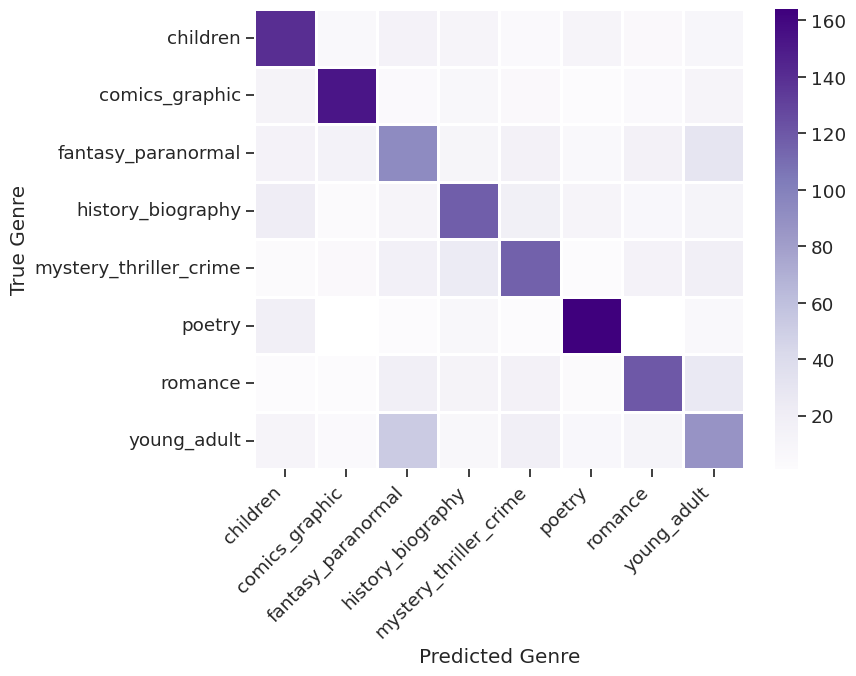

In [ ]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

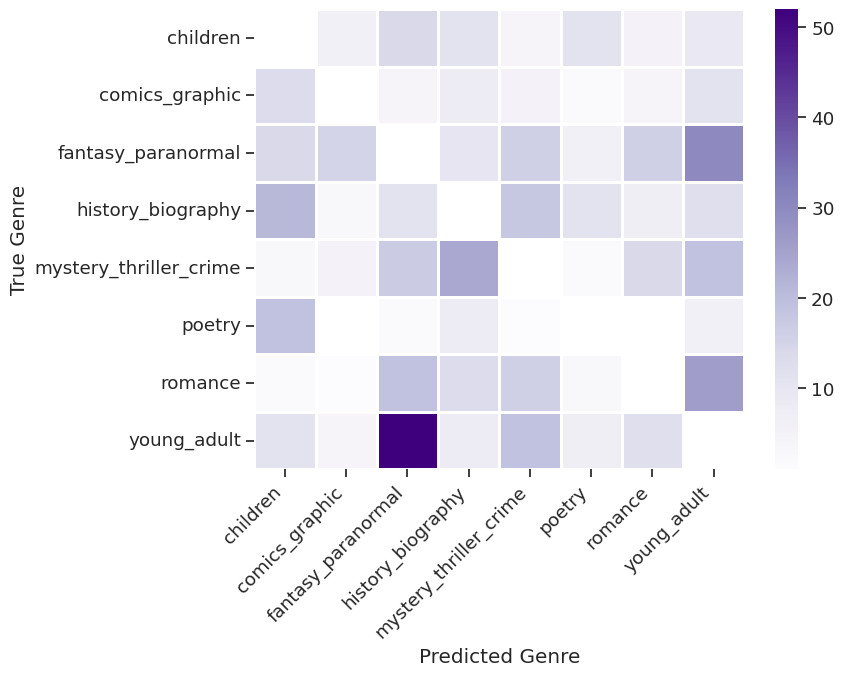

In [ ]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()